## 1. Load Dữ Liệu

In [1]:
from datasets import load_dataset
import pandas as pd

data_files = {
    "train": "/kaggle/input/datasets/iceemperoz/train-valid-summarization/train-00000-of-00001.parquet",       
    "validation": "/kaggle/input/datasets/iceemperoz/train-valid-summarization/valid-00000-of-00001.parquet"
}

raw_datasets = load_dataset("parquet", data_files=data_files)
print(raw_datasets)
print(f"\nTrain raw : {len(raw_datasets['train'])} mẫu")
print(f"Valid raw : {len(raw_datasets['validation'])} mẫu")

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['article', 'summary'],
        num_rows: 10775
    })
    validation: Dataset({
        features: ['article', 'summary'],
        num_rows: 1349
    })
})

Train raw : 10775 mẫu
Valid raw : 1349 mẫu


## 2. Exploratory Data Analysis (EDA)

--- KIỂM TRA DỮ LIỆU THÔ ---
                                            document  \
0  Gần 20 sự kiện được tổ chức trên toàn thành ph...   
1  Được thành lập năm 1897 tại Đức, Kempinski Hot...   

                                             summary  
0  Hà Nội tổ chức gần 20 sự kiện từ 19/4 đến 10/5...  
1  Kempinski Hotels là một thương hiệu nổi tiếng ...  
        doc_len  summary_len     ratio
count  10775.00     10775.00  10775.00
mean     458.15       102.58      0.23
std       99.54        21.84      0.06
min      300.00        50.00      0.08
25%      381.00        86.00      0.19
50%      444.00       100.00      0.23
75%      515.00       118.00      0.27
max      700.00       174.00      0.49


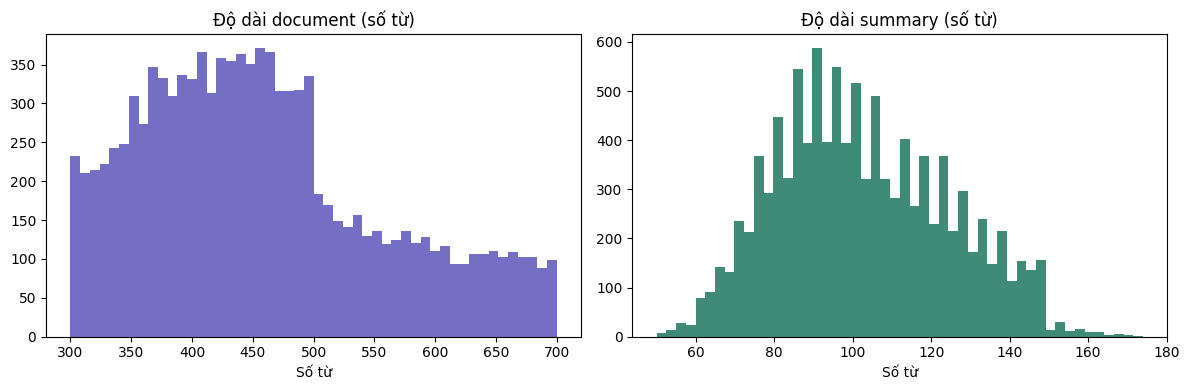

In [2]:
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "document": raw_datasets["train"]["article"],
    "summary": raw_datasets["train"]["summary"]
})

print("--- KIỂM TRA DỮ LIỆU THÔ ---")
print(df.head(2))

df["doc_len"]     = df["document"].apply(lambda x: len(str(x).split()))
df["summary_len"] = df["summary"].apply(lambda x: len(str(x).split()))
df["ratio"]       = df["summary_len"] / df["doc_len"]

print(df[["doc_len", "summary_len", "ratio"]].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["doc_len"].clip(0, 1000), bins=50, color="#534AB7", alpha=0.8)
axes[0].set_title("Độ dài document (số từ)")
axes[0].set_xlabel("Số từ")
axes[1].hist(df["summary_len"].clip(0, 300), bins=50, color="#0F6E56", alpha=0.8)
axes[1].set_title("Độ dài summary (số từ)")
axes[1].set_xlabel("Số từ")
plt.tight_layout()
plt.savefig("eda_length_dist.png", dpi=150)
plt.show()

## 3. Làm Sạch Dữ Liệu

In [3]:
import re, unicodedata

def clean_text(text: str) -> str:
    text = unicodedata.normalize("NFC", str(text))
    text = re.sub(r"<[^>]+>", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def is_valid(doc, summ):
    d, s = len(doc.split()), len(summ.split())
    return d >= 50 and s >= 10 and s < d

def build_clean_df(split) -> pd.DataFrame:
    df = pd.DataFrame({
        'document_clean': [clean_text(x) for x in split['article']],
        'summary_clean' : [clean_text(x) for x in split['summary']],
    })
    before = len(df)
    df = df[df.apply(
        lambda r: is_valid(r['document_clean'], r['summary_clean']), axis=1
    )].reset_index(drop=True)
    print(f'  {before} → {len(df)} mẫu sau lọc')
    return df

print('Làm sạch train...')
train_df = build_clean_df(raw_datasets['train'])

print('Làm sạch validation...')
val_full_df = build_clean_df(raw_datasets['validation'])

Làm sạch train...
  10775 → 10775 mẫu sau lọc
Làm sạch validation...
  1349 → 1349 mẫu sau lọc


In [4]:
n = len(train_df)

df_train = train_df.copy() 

train_df  = df_train.iloc[:int(n*0.9)].reset_index(drop=True)
test_df   = df_train.iloc[int(n*0.9):].reset_index(drop=True)
val_df    = val_full_df.reset_index(drop = True) 

print('=' * 50)
print(f'Train : {len(train_df):>6} mẫu  ← từ train parquet (90%)')
print(f'Val   : {len(val_df):>6} mẫu')
print(f'Test  : {len(test_df):>6} mẫu  ← từ train parquet (10%)')
print('=' * 50)

train_docs = set(train_df['document_clean'].astype(str).str[:100])
val_docs   = set(val_df['document_clean'].astype(str).str[:100])
test_docs  = set(test_df['document_clean'].astype(str).str[:100])

print(f'\nOverlap train ∩ val  : {len(train_docs & val_docs)} mẫu')
print(f'Overlap train ∩ test : {len(train_docs & test_docs)} mẫu')
print(f'Overlap val   ∩ test : {len(val_docs & test_docs)} mẫu')

Train :   9697 mẫu  ← từ train parquet (90%)
Val   :   1349 mẫu
Test  :   1078 mẫu  ← từ train parquet (10%)

Overlap train ∩ val  : 1 mẫu
Overlap train ∩ test : 0 mẫu
Overlap val   ∩ test : 0 mẫu


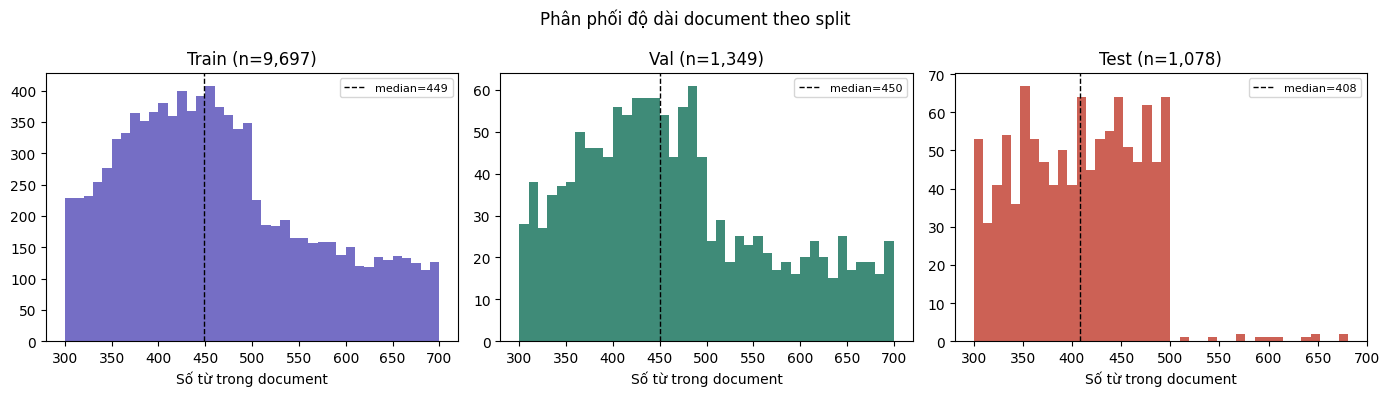


===== THỐNG KÊ ĐỘ DÀI DOCUMENT =====
        Train     Val    Test
count  9697.0  1349.0  1078.0
mean    463.9   466.4   406.7
std     101.3   102.6    61.3
min     300.0   300.0   300.0
25%     385.0   388.0   356.0
50%     449.0   450.0   408.0
75%     529.0   533.0   455.8
max     700.0   700.0   681.0


In [5]:
import matplotlib.pyplot as plt
import numpy as np

# So sánh phân phối độ dài giữa 3 split — phải tương đồng
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
splits = {'Train': train_df, 'Val': val_df, 'Test': test_df}
colors = ['#534AB7', '#0F6E56', '#C0392B']

for ax, (name, df_), color in zip(axes, splits.items(), colors):
    doc_lens = df_['document_clean'].apply(lambda x: len(x.split()))
    ax.hist(doc_lens.clip(0, 800), bins=40, color=color, alpha=0.8)
    ax.set_title(f'{name} (n={len(df_):,})')
    ax.set_xlabel('Số từ trong document')
    ax.axvline(doc_lens.median(), color='black', linestyle='--',
               linewidth=1, label=f'median={doc_lens.median():.0f}')
    ax.legend(fontsize=8)

plt.suptitle('Phân phối độ dài document theo split', fontsize=12)
plt.tight_layout()
plt.savefig('split_distribution.png', dpi=150)
plt.show()

# Bảng thống kê tóm tắt
stats = pd.DataFrame({
    split_name: df_['document_clean'].apply(lambda x: len(x.split())).describe().round(1)
    for split_name, df_ in splits.items()
})
print('\n===== THỐNG KÊ ĐỘ DÀI DOCUMENT =====')
print(stats)

In [6]:
# Lưu các split
train_df.to_csv('/kaggle/working/train_clean.csv',  index=False)
val_df.to_csv('/kaggle/working/val_clean.csv',    index=False)
test_df.to_csv('/kaggle/working/test_clean.csv',   index=False)

print('Đã lưu:')
print('  /kaggle/working/train_clean.csv')
print('  /kaggle/working/val_clean.csv')
print('  /kaggle/working/test_clean.csv')

Đã lưu:
  /kaggle/working/train_clean.csv
  /kaggle/working/val_clean.csv
  /kaggle/working/test_clean.csv


## 4. Extractive Baseline

Xây dựng baseline bằng 2 phương pháp:
- **TextRank**: TF-IDF + cosine similarity, chọn câu đại diện nhất cho toàn văn bản
- **LexRank**: Cải tiến TextRank dùng đồ thị similarity chuẩn hóa

Mục đích: có điểm ROUGE làm **mốc so sánh** với fine-tuned model.

In [7]:
!pip install sumy rouge-score nltk -q

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 70.4 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 102.7 MB/s eta 0:00:0000:01


In [8]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("test_clean.csv")
df_test = df.sample(500, random_state=42).reset_index(drop=True)
print(f"Đang đánh giá trên {len(df_test)} mẫu")

Đang đánh giá trên 500 mẫu


### 4.1 TextRank (TF-IDF + Cosine Similarity)

In [9]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def textrank_summarize(text: str, n_sentences: int = 3) -> str:
    """
    Extractive summarization bằng TF-IDF TextRank:
    1. Tách câu theo dấu câu
    2. Tính TF-IDF vector cho mỗi câu
    3. Tính cosine similarity với centroid (mean vector)
    4. Chọn top-n câu có score cao nhất, giữ thứ tự gốc
    """
    sentences = [s.strip() for s in
                 __import__('re').split(r'(?<=[.!?])\s+', text)
                 if len(s.split()) > 5]

    if len(sentences) <= n_sentences:
        return text

    vectorizer   = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(sentences)
    centroid     = np.asarray(tfidf_matrix.mean(axis=0))
    scores       = cosine_similarity(tfidf_matrix, centroid).flatten()
    top_idx      = sorted(np.argsort(scores)[-n_sentences:])

    return " ".join([sentences[i] for i in top_idx])

### 4.2 LexRank (Graph-based Similarity)

In [10]:
from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer
from sumy.summarizers.lex_rank import LexRankSummarizer

def lexrank_summarize(text: str, n_sentences: int = 3) -> str:
    """LexRank — cải tiến TextRank dùng đồ thị similarity chuẩn hóa"""
    try:
        parser     = PlaintextParser.from_string(text, Tokenizer("english"))
        summarizer = LexRankSummarizer()
        summary    = summarizer(parser.document, n_sentences)
        return " ".join([str(s) for s in summary])
    except:
        return text[:500]

### 4.3 Đánh giá ROUGE Baseline

In [11]:
from rouge_score import rouge_scorer
import numpy as np

scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=False)

def evaluate_method(df, summarize_fn, method_name, n_sent=3):
    r1, r2, rl = [], [], []
    for _, row in df.iterrows():
        pred = summarize_fn(row["document_clean"], n_sent)
        ref  = row["summary_clean"]
        s    = scorer.score(ref, pred)
        r1.append(s["rouge1"].fmeasure)
        r2.append(s["rouge2"].fmeasure)
        rl.append(s["rougeL"].fmeasure)
    result = {
        "Method" : method_name,
        "ROUGE-1": round(np.mean(r1) * 100, 2),
        "ROUGE-2": round(np.mean(r2) * 100, 2),
        "ROUGE-L": round(np.mean(rl) * 100, 2),
    }
    print(result)
    return result

results = []
print("Đang chạy TextRank...")
results.append(evaluate_method(df_test, textrank_summarize, "TextRank (TF-IDF)"))
print("Đang chạy LexRank...")
results.append(evaluate_method(df_test, lexrank_summarize, "LexRank (sumy)"))

Đang chạy TextRank...
{'Method': 'TextRank (TF-IDF)', 'ROUGE-1': np.float64(70.47), 'ROUGE-2': np.float64(41.47), 'ROUGE-L': np.float64(42.84)}
Đang chạy LexRank...
{'Method': 'LexRank (sumy)', 'ROUGE-1': np.float64(69.92), 'ROUGE-2': np.float64(40.86), 'ROUGE-L': np.float64(42.18)}



===== BASELINE RESULTS =====
           Method  ROUGE-1  ROUGE-2  ROUGE-L
TextRank (TF-IDF)    70.47    41.47    42.84
   LexRank (sumy)    69.92    40.86    42.18


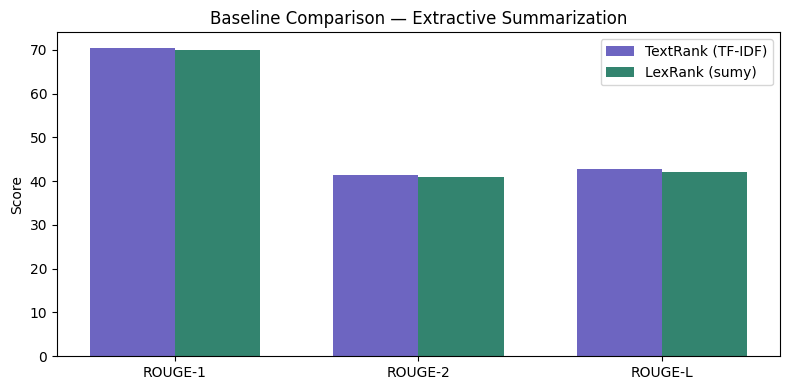

Đã lưu baseline_scores.csv


In [12]:
import matplotlib.pyplot as plt

df_results = pd.DataFrame(results)
print("\n===== BASELINE RESULTS =====")
print(df_results.to_string(index=False))

metrics = ["ROUGE-1", "ROUGE-2", "ROUGE-L"]
x = np.arange(len(metrics))
width = 0.35
colors = ["#534AB7", "#0F6E56"]

fig, ax = plt.subplots(figsize=(8, 4))
for i, row in df_results.iterrows():
    ax.bar(x + i*width, [row[m] for m in metrics],
           width, label=row["Method"], color=colors[i], alpha=0.85)
ax.set_xticks(x + width/2)
ax.set_xticklabels(metrics)
ax.set_ylabel("Score")
ax.set_title("Baseline Comparison — Extractive Summarization")
ax.legend()
plt.tight_layout()
plt.savefig("baseline_rouge.png", dpi=150)
plt.show()

df_results.to_csv("baseline_scores.csv", index=False)
print("Đã lưu baseline_scores.csv")

In [13]:
# Phân tích định tính — xem model baseline sai ở đâu
print("PHÂN TÍCH ĐỊNH TÍNH — 3 mẫu đầu\n")

for i in range(3):
    row    = df_test.iloc[i]
    pred   = textrank_summarize(row["document_clean"])
    ref    = row["summary_clean"]
    s      = scorer.score(ref, pred)
    print(f"--- Mẫu {i+1} | ROUGE-1: {s['rouge1'].fmeasure:.2f} ---")
    print(f"[DOCUMENT]  {row['document_clean'][:300]}...")
    print(f"[PREDICTED] {pred[:300]}")
    print(f"[REFERENCE] {ref[:300]}")
    print()

PHÂN TÍCH ĐỊNH TÍNH — 3 mẫu đầu

--- Mẫu 1 | ROUGE-1: 0.64 ---
[DOCUMENT]  Ông Giang được bầu làm Chủ tịch UBND tỉnh Quảng Ngãi nhiệm kỳ 2021-2026 tại kỳ họp thứ 26 của HĐND tỉnh Quảng Ngãi khóa 13; với 45/45 tổng số phiếu bầu, đạt 100% tổng số đại biểu có mặt. Phát biểu sau khi nhận nhiệm vụ, tân chủ tịch UBND tỉnh Quảng Ngãi cho biết đây là vinh dự đối với cá nhân, đồng ...
[PREDICTED] Trước đó, hôm 31/7, ông Nguyễn Hoàng Giang được Phó Ban Tổ chức Trung ương Hoàng Đăng Quang trao quyết định của Ban Bí thư về việc điều động, chỉ định tham gia Ban Chấp hành, Ban Thường vụ và giữ chức Phó bí thư Tỉnh ủy Quảng Ngãi, nhiệm kỳ 2020-2025; giới thiệu để HĐND tỉnh bầu làm chủ tịch UBND tỉ
[REFERENCE] Tân Chủ tịch UBND tỉnh Quảng Ngãi, ông Nguyễn Hoàng Giang, đã được bầu chọn với 45/45 tổng số phiếu, đạt 100% tổng số đại biểu có mặt. Ông cho biết đây là vinh dự và nhiệm vụ nặng nề, ông sẽ tiếp tục phát huy thành quả của các thế hệ đi trước và nỗ lực hoàn thành nhiệm vụ được giao. Ông Giang, 5

## 5. Fine-tune BARTpho với LoRA

In [ ]:
!pip install transformers datasets rouge-score sentencepiece -q
!pip install accelerate peft bert-score -q

In [ ]:
import torch
import pandas as pd
import numpy as np
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM,
    Seq2SeqTrainer, Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq, EarlyStoppingCallback
)
from rouge_score import rouge_scorer

print("GPU available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory/1e9, 1), "GB")

In [ ]:
train_df = pd.read_csv('/kaggle/working/train_clean.csv').dropna().reset_index(drop=True)
val_df   = pd.read_csv('/kaggle/working/val_clean.csv').dropna().reset_index(drop=True)
test_df  = pd.read_csv('/kaggle/working/test_clean.csv').dropna().reset_index(drop=True)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

### 5.1 Load Model & Cấu Hình LoRA

In [ ]:
from peft import LoraConfig, get_peft_model, TaskType

tokenizer = AutoTokenizer.from_pretrained("vinai/bartpho-syllable")
model     = AutoModelForSeq2SeqLM.from_pretrained("vinai/bartpho-syllable")
model     = model.to("cuda")

lora_config = LoraConfig(
    task_type      = TaskType.SEQ_2_SEQ_LM,
    r              = 16,
    lora_alpha     = 32,
    lora_dropout   = 0.1,
    target_modules = ["q_proj", "v_proj", "k_proj", "out_proj", "fc1", "fc2"],
    bias           = "none",
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()
print(f"Model params: {sum(p.numel() for p in model.parameters())/1e6:.0f}M")

MAX_INPUT  = 512
MAX_TARGET = 128

def tokenize_fn(batch):
    model_inputs = tokenizer(
        batch["document_clean"],
        max_length=MAX_INPUT, truncation=True, padding=False,
    )
    labels = tokenizer(
        text_target=batch["summary_clean"],
        max_length=MAX_TARGET, truncation=True, padding=False,
    )
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

train_ds  = Dataset.from_pandas(train_df[["document_clean", "summary_clean"]])
val_ds    = Dataset.from_pandas(val_df[["document_clean",   "summary_clean"]])
test_ds   = Dataset.from_pandas(test_df[["document_clean",  "summary_clean"]])

train_tok = train_ds.map(tokenize_fn, batched=True, remove_columns=train_ds.column_names)
val_tok   = val_ds.map(tokenize_fn,   batched=True, remove_columns=val_ds.column_names)
test_tok  = test_ds.map(tokenize_fn,  batched=True, remove_columns=test_ds.column_names)

print("Tokenize xong!")
print(train_tok)

### 5.3 Training

In [ ]:
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model, padding=True)

training_args = Seq2SeqTrainingArguments(
    output_dir                  = "/kaggle/working/bartpho-lora",
    num_train_epochs            = 5,
    per_device_train_batch_size = 8,
    gradient_accumulation_steps = 1,    # Tích lũy 4 bước để Tổng Batch Size hiệu dụng vẫn bằng 16 (4 x 4 = 16)
    per_device_eval_batch_size  = 8,
    
    gradient_checkpointing      = True, 
    warmup_steps                = 200,
    weight_decay                = 0.01,
    learning_rate               = 3e-4,
    lr_scheduler_type           = "cosine",
    label_smoothing_factor      = 0.05,
    
    predict_with_generate       = True,
    generation_max_length       = 128,
    generation_num_beams        = 4,

    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    save_total_limit            = 2,
    load_best_model_at_end      = True,
    metric_for_best_model       = "eval_loss",
    fp16                        = True,

    dataloader_num_workers      = 2,
    logging_steps               = 50,
    report_to                   = "none",
)

trainer = Seq2SeqTrainer(
    model            = model,
    args             = training_args,
    train_dataset    = train_tok,
    eval_dataset     = val_tok,
    processing_class = tokenizer,
    data_collator    = data_collator,
    callbacks        = [EarlyStoppingCallback(early_stopping_patience=2)],
)

print("Bắt đầu train...")
trainer.train()

In [ ]:
# Vẽ train loss vs val loss để kiểm tra overfitting
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_steps  = [x['step'] for x in log_history if 'loss' in x and 'eval_loss' not in x]
train_losses = [x['loss'] for x in log_history if 'loss' in x and 'eval_loss' not in x]
eval_steps   = [x['step'] for x in log_history if 'eval_loss' in x]
eval_losses  = [x['eval_loss'] for x in log_history if 'eval_loss' in x]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_steps, train_losses, color='#534AB7', alpha=0.6, label='Train loss')
ax.plot(eval_steps,  eval_losses,  color='#C0392B', linewidth=2,
        marker='o', markersize=5, label='Val loss (valid parquet)')
ax.set_xlabel('Step')
ax.set_ylabel('Loss')
ax.set_title('Training curve — val từ valid parquet (unseen)')
ax.legend()
plt.tight_layout()
plt.savefig('training_curve_v2.png', dpi=150)
plt.show()

# Phát hiện overfitting sớm
if len(eval_losses) >= 2:
    trend = eval_losses[-1] - min(eval_losses)
    if trend > 0.05:
        print(f'⚠️  Val loss tăng {trend:.3f} so với best — dấu hiệu overfit!')
        print('   → Early stopping đã kích hoạt đúng lúc.')
    else:
        print(f'✓ Val loss ổn định (delta = {trend:.3f})')

In [ ]:
LORA_PATH = "/kaggle/working/bartpho-lora/adapter"
model.save_pretrained(LORA_PATH)
tokenizer.save_pretrained(LORA_PATH)

SAVE_PATH = "/kaggle/working/bartpho-summarization/best-model"
trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)
print(f"✓ Model đã lưu tại: {SAVE_PATH}")
print(f"✓ LoRA adapter tại: {LORA_PATH}")

## 6. Inference

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from peft import PeftModel
import torch

inf_tokenizer = AutoTokenizer.from_pretrained("vinai/bartpho-syllable")
base_model    = AutoModelForSeq2SeqLM.from_pretrained("vinai/bartpho-syllable")
inf_model     = PeftModel.from_pretrained(base_model, LORA_PATH)
inf_model     = inf_model.merge_and_unload() 
inf_model     = inf_model.to("cuda")
inf_model.eval()

print("✓ Model loaded & merged")


def summarize(text: str, max_len=128, min_len=30) -> str:
    """Standard summarize — truncate cứng ở 512 token."""
    inputs = inf_tokenizer(
        text, return_tensors="pt",
        max_length=512, truncation=True
    ).to("cuda")
    with torch.no_grad():
        output_ids = inf_model.generate(
            **inputs,
            max_length           = max_len,
            min_length           = min_len,
            num_beams            = 4,
            length_penalty       = 2.0,
            no_repeat_ngram_size = 3,
            early_stopping       = True,
        )
    return inf_tokenizer.decode(output_ids[0], skip_special_tokens=True)

### 6.2 Inference với TF-IDF Re-ranking


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def summarize_with_reranking(text: str,
                              num_candidates: int = 6,
                              max_len: int = 128,
                              min_len: int = 20) -> str:
    """
    Diverse beam search → 6 candidates
    TF-IDF cosine similarity với document → chọn best
    """
    inputs = inf_tokenizer(
        text, return_tensors="pt",
        max_length=512, truncation=True
    ).to("cuda")

    with torch.no_grad():
        output_ids = inf_model.generate(
            **inputs,
            num_beams            = num_candidates,
            num_beam_groups      = num_candidates // 2,  # 3 groups × 2 beams
            diversity_penalty    = 0.8,
            num_return_sequences = num_candidates,
            max_length           = max_len,
            min_length           = min_len,
            no_repeat_ngram_size = 3,
            early_stopping       = True,
            trust_remote_code    = True
        )

    candidates = [
        inf_tokenizer.decode(ids, skip_special_tokens=True)
        for ids in output_ids
    ]

    try:
        corpus     = [text] + candidates
        vectorizer = TfidfVectorizer(max_features=5000)
        tfidf_mat  = vectorizer.fit_transform(corpus)
        scores     = cosine_similarity(tfidf_mat[0:1], tfidf_mat[1:]).flatten()
        best_idx   = int(np.argmax(scores))
        return candidates[best_idx]
    except Exception:
        return candidates[0]  # fallback

sample_doc = test_df.iloc[0]["document_clean"]
print("Standard   :", summarize(sample_doc))
print("Re-ranking :", summarize_with_reranking(sample_doc))

## Reward-Weighted SFT


In [ ]:
!pip install -q trl

In [ ]:
import gc
import torch
import pandas as pd
from datasets import Dataset
from bert_score import BERTScorer
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from peft import PeftModel

LORA_PATH = "/kaggle/working/bartpho-lora/adapter"

# Load lại SFT model
base_model = AutoModelForSeq2SeqLM.from_pretrained("vinai/bartpho-syllable")
sft_model  = PeftModel.from_pretrained(base_model, LORA_PATH)
sft_model  = sft_model.merge_and_unload().to("cuda")
sft_model.eval()
tokenizer  = AutoTokenizer.from_pretrained("vinai/bartpho-syllable")

bert_scorer = BERTScorer(lang="vi", model_type="bert-base-multilingual-cased", device="cuda")

def generate_preference_dataset(model, tokenizer, df, scorer, num_samples=800):
    data      = []
    sample_df = df.sample(min(num_samples, len(df)), random_state=42).reset_index(drop=True)

    with torch.no_grad():
        for _, row in tqdm(sample_df.iterrows(), total=len(sample_df), desc="Tạo preference data"):
            prompt    = row["document_clean"].strip()
            reference = row["summary_clean"].strip()

            inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to("cuda")

            # Chosen: Beam search (chất lượng cao)
            chosen_ids = model.generate(
                **inputs, num_beams=4, max_length=128, min_length=20,
                early_stopping=True, no_repeat_ngram_size=3, length_penalty=2.0
            )
            chosen = tokenizer.decode(chosen_ids[0], skip_special_tokens=True).strip()

            # Rejected: Sampling (chất lượng thấp hơn)
            rejected_ids = model.generate(
                **inputs, do_sample=True, temperature=1.0, max_length=128,
                min_length=20, top_p=0.95, no_repeat_ngram_size=3
            )
            rejected = tokenizer.decode(rejected_ids[0], skip_special_tokens=True).strip()

            _, _, F1_chosen = scorer.score([chosen],   [reference])
            _, _, F1_rej    = scorer.score([rejected], [reference])

            if F1_chosen[0].item() >= F1_rej[0].item():
                data.append({
                    "prompt": prompt, "chosen": chosen, "rejected": rejected,
                    "score_chosen": F1_chosen[0].item(), "score_rejected": F1_rej[0].item()
                })
            else:
                data.append({
                    "prompt": prompt, "chosen": rejected, "rejected": chosen,
                    "score_chosen": F1_rej[0].item(), "score_rejected": F1_chosen[0].item()
                })

    return Dataset.from_pandas(pd.DataFrame(data))

pref_dataset = generate_preference_dataset(sft_model, tokenizer, train_df, bert_scorer, num_samples=800)
print(pref_dataset)

pref_dataset.to_parquet("/kaggle/working/pref_dataset.parquet")

del sft_model
del bert_scorer
torch.cuda.empty_cache()
gc.collect()
print("Preference dataset đã tạo và lưu thành công!")


In [ ]:
import torch
import numpy as np
import pandas as pd
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM,
    Seq2SeqTrainer, Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq
)
from peft import PeftModel

LORA_PATH = "/kaggle/working/bartpho-lora/adapter"
MAX_INPUT  = 512
MAX_TARGET = 128

rwsft_df = pd.DataFrame({
    "document_clean": pref_dataset["prompt"],
    "summary_clean":  pref_dataset["chosen"],
    "score":          pref_dataset["score_chosen"],
})

# Tùy chọn: Lọc thêm, chỉ giữ những mẫu có BERTScore F1 cao nhất (top 70%)
threshold = rwsft_df["score"].quantile(0.30)
rwsft_df  = rwsft_df[rwsft_df["score"] >= threshold].reset_index(drop=True)
print(f"Tổng mẫu Reward-Weighted SFT (top 70% BERTScore): {len(rwsft_df)}")

# Bước 2: Tokenize 
tokenizer = AutoTokenizer.from_pretrained("vinai/bartpho-syllable")

def tokenize_fn(batch):
    model_inputs = tokenizer(
        batch["document_clean"],
        max_length=MAX_INPUT, truncation=True, padding=False,
    )
    labels = tokenizer(
        text_target=batch["summary_clean"],
        max_length=MAX_TARGET, truncation=True, padding=False,
    )
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

rwsft_ds   = Dataset.from_pandas(rwsft_df[["document_clean", "summary_clean"]])
val_ds_tok = Dataset.from_pandas(val_df[["document_clean", "summary_clean"]])

rwsft_split  = rwsft_ds.train_test_split(test_size=0.1, seed=42)
rwsft_train  = rwsft_split["train"].map(tokenize_fn, batched=True, remove_columns=["document_clean", "summary_clean"])
rwsft_eval   = rwsft_split["test"].map(tokenize_fn,  batched=True, remove_columns=["document_clean", "summary_clean"])

print(f"Train: {len(rwsft_train)} | Eval: {len(rwsft_eval)}")

# Bước 3: Load lại SFT model với LoRA trainable 
base_model  = AutoModelForSeq2SeqLM.from_pretrained("vinai/bartpho-syllable")
rwsft_model = PeftModel.from_pretrained(base_model, LORA_PATH, is_trainable=True)
rwsft_model = rwsft_model.to("cuda")
rwsft_model.print_trainable_parameters()

# Bước 4: Cấu hình Trainer 
data_collator = DataCollatorForSeq2Seq(tokenizer, model=rwsft_model, padding=True)

training_args = Seq2SeqTrainingArguments(
    output_dir                  = "/kaggle/working/bartpho-rwsft",
    num_train_epochs            = 2,          # Chỉ cần 1-2 epoch
    per_device_train_batch_size = 4,
    gradient_accumulation_steps = 2,          
    per_device_eval_batch_size  = 4,
    learning_rate               = 2e-5,       
    lr_scheduler_type           = "cosine",
    warmup_steps                = 50,
    weight_decay                = 0.01,
    label_smoothing_factor      = 0.05,

    predict_with_generate       = True,
    generation_max_length       = 128,
    generation_num_beams        = 4,

    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    save_total_limit            = 1,
    load_best_model_at_end      = True,
    metric_for_best_model       = "eval_loss",
    fp16                        = True,

    logging_steps               = 20,
    report_to                   = "none",
)

rwsft_trainer = Seq2SeqTrainer(
    model            = rwsft_model,
    args             = training_args,
    train_dataset    = rwsft_train,
    eval_dataset     = rwsft_eval,
    processing_class = tokenizer,
    data_collator    = data_collator,
)

In [ ]:
import torch
from peft import PeftModel
from transformers import AutoModelForSeq2SeqLM

# Train
print("Bắt đầu Reward-Weighted SFT...")
rwsft_trainer.train()

# Lưu adapter
RWSFT_ADAPTER_PATH = "/kaggle/working/bartpho-rwsft/adapter"
rwsft_model.save_pretrained(RWSFT_ADAPTER_PATH)
tokenizer.save_pretrained(RWSFT_ADAPTER_PATH)
print(f"Đã lưu adapter tại: {RWSFT_ADAPTER_PATH}")